# LumenY — 03: Model Training (Quantile Regression)

**Architecture:** 5 quantile models × 4 horizons = 20 LightGBM models total.

**Quantiles:** Q10, Q25, Q50, Q75, Q90

**Output per inference:** 5 return percentiles → direction probability, expected move, cone boundaries.

**Validation:** Walk-forward only. Quantile coverage calibration.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import mean_pinball_loss

FEATURES_DIR = Path('../backend/data/features')
MODELS_DIR   = Path('../backend/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS  = ['1H', '4H', '1D', '7D']
QUANTILES = [0.10, 0.25, 0.50, 0.75, 0.90]
QUANTILE_NAMES = ['Q10', 'Q25', 'Q50', 'Q75', 'Q90']

print('Ready.')
print(f'Total models to train: {len(HORIZONS) * len(QUANTILES)}')

Ready.
Total models to train: 20


## 1. Load Dataset

In [2]:
df = pd.read_parquet(FEATURES_DIR / 'all_pairs_features_labels.parquet')

label_cols   = [f'label_{h}' for h in HORIZONS]
drop_cols    = label_cols + ['pair']
feature_cols = [c for c in df.columns if c not in drop_cols]

print(f'Shape:     {df.shape}')
print(f'Features:  {len(feature_cols)}')
print(f'Date range: {df.index[0].date()} -> {df.index[-1].date()}')
print(f'Pairs:     {df["pair"].unique()}')

Shape:     (685111, 213)
Features:  208
Date range: 2009-09-25 -> 2025-12-19
Pairs:     ['EURUSD' 'GBPUSD' 'NZDUSD' 'AUDUSD' 'USDCHF' 'USDCAD' 'USDJPY']


## 2. Walk-Forward Splits

In [3]:
def walk_forward_splits(n, n_splits=5, test_ratio=0.1):
    test_size = int(n * test_ratio)
    splits = []
    for i in range(n_splits):
        test_start = int(n * 0.5) + i * (int(n * 0.5) // n_splits)
        test_end   = test_start + test_size
        if test_end > n:
            break
        splits.append((list(range(0, test_start)), list(range(test_start, test_end))))
    return splits

splits = walk_forward_splits(len(df))
print(f'Walk-forward splits: {len(splits)}')
for i, (train_idx, test_idx) in enumerate(splits):
    print(f'  Fold {i+1}: Train {df.index[train_idx[0]].date()} to {df.index[train_idx[-1]].date()} | Test {df.index[test_idx[0]].date()} to {df.index[test_idx[-1]].date()} ({len(test_idx):,} rows)')

Walk-forward splits: 5
  Fold 1: Train 2009-09-25 to 2017-10-16 | Test 2017-10-16 to 2019-05-29 (68,511 rows)
  Fold 2: Train 2009-09-25 to 2019-05-29 | Test 2019-05-29 to 2021-02-17 (68,511 rows)
  Fold 3: Train 2009-09-25 to 2021-02-17 | Test 2021-02-17 to 2022-09-30 (68,511 rows)
  Fold 4: Train 2009-09-25 to 2022-09-30 | Test 2022-09-30 to 2024-05-09 (68,511 rows)
  Fold 5: Train 2009-09-25 to 2024-05-09 | Test 2024-05-09 to 2025-12-19 (68,511 rows)


## 3. LightGBM Quantile Config

In [4]:
def get_lgbm_params(quantile):
    return {
        'objective':         'quantile',
        'alpha':             quantile,
        'metric':            'quantile',
        'boosting_type':     'gbdt',
        'n_estimators':      5000,
        'learning_rate':     0.02,
        'num_leaves':        64,
        'max_depth':         6,
        'min_child_samples': 50,
        'feature_fraction':  0.7,
        'bagging_fraction':  0.8,
        'bagging_freq':      5,
        'reg_alpha':         0.1,
        'reg_lambda':        0.1,
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
        'device': 'gpu',
    }

print('Params ready. objective=quantile with pinball loss.')

Params ready. objective=quantile with pinball loss.


In [5]:
# quick check 
# Verify dataset has all expected features
df = pd.read_parquet(FEATURES_DIR / 'all_pairs_features_labels.parquet')

# Check correlation features present
corr_cols = [c for c in df.columns if c.startswith('corr_')]
pc1_cols  = [c for c in df.columns if c.startswith('pc1_')]

print(f'Total features: {len([c for c in df.columns if c not in [f"label_{h}" for h in ["1H","4H","1D","7D"]] + ["pair"]])}')
print(f'Correlation features: {len(corr_cols)} → {corr_cols}')
print(f'PC1 features: {len(pc1_cols)} → {pc1_cols}')

Total features: 208
Correlation features: 17 → ['corr_GBPUSD_24H', 'corr_USDJPY_24H', 'corr_USDCHF_24H', 'corr_AUDUSD_24H', 'corr_USDCAD_24H', 'corr_NZDUSD_24H', 'corr_GBPUSD_1W', 'corr_USDJPY_1W', 'corr_USDCHF_1W', 'corr_AUDUSD_1W', 'corr_USDCAD_1W', 'corr_NZDUSD_1W', 'corr_mean_abs_24H', 'corr_std_24H', 'corr_mean_abs_1W', 'corr_EURUSD_24H', 'corr_EURUSD_1W']
PC1 features: 2 → ['pc1_share_24H', 'pc1_share_1W']


In [7]:
import lightgbm as lgb
import numpy as np

try:
    data = lgb.Dataset(np.array([[1,2],[3,4]], dtype=np.float32), label=np.array([1,0], dtype=np.float32))
    params = {'device': 'gpu', 'verbose': -1, 'objective': 'regression'}
    model = lgb.train(params, data, num_boost_round=5)
    print('GPU recognized and working.')
except Exception as e:
    print(f'GPU not available: {e}')

GPU recognized and working.


## 4. Train All 20 Models

In [8]:
all_results = {}
X = df[feature_cols].ffill().bfill()

for horizon in HORIZONS:
    print(f'\n{"="*55}')
    print(f'HORIZON: {horizon}')
    print(f'{"="*55}')

    y = df[f'label_{horizon}']
    valid_mask = y.notna() 
    X_clean = X[valid_mask]
    y_clean = y[valid_mask]
    print(f'Samples: {len(X_clean):,}')

    horizon_results = {}
    splits = walk_forward_splits(len(X_clean))
    oof_preds  = {q: np.full(len(X_clean), np.nan) for q in QUANTILES}
    best_iters = {q: [] for q in QUANTILES}

    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        print(f'\n  Training {q_name} (alpha={q})...')
        params = get_lgbm_params(q)
        fold_pinball = []

        for fold, (train_idx, test_idx) in enumerate(splits):
            X_train = X_clean.iloc[train_idx]
            y_train = y_clean.iloc[train_idx]
            X_test  = X_clean.iloc[test_idx]
            y_test  = y_clean.iloc[test_idx]

            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_train, y_train,
                eval_set=[(X_test, y_test)],
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
            )

            preds = model.predict(X_test)
            oof_preds[q][test_idx] = preds
            fold_pinball.append(mean_pinball_loss(y_test, preds, alpha=q))
            best_iters[q].append(model.best_iteration_)

        mean_pb = np.mean(fold_pinball)
        print(f'    CV Pinball: {mean_pb:.6f} | Best iters: {best_iters[q]}')

        # Train final model
        avg_iter = max(50, int(np.mean(best_iters[q])))
        final_model = lgb.LGBMRegressor(**{**params, 'n_estimators': avg_iter})
        final_model.fit(X_clean, y_clean)

        q_int = int(q * 100)
        joblib.dump({'model': final_model, 'quantile': q, 'horizon': horizon, 'feature_cols': feature_cols},
                    MODELS_DIR / f'model_{horizon}_Q{q_int}.joblib')

        horizon_results[q_name] = {'pinball': mean_pb}

    # Quantile coverage
    print(f'\n  Quantile Coverage (OOF):')
    print(f'  {"Quantile":<10} {"Target":<10} {"Actual":<10} {"Gap"}')
    print(f'  {"-"*42}')

    valid_oof = ~np.isnan(oof_preds[QUANTILES[0]])
    y_oof = y_clean.values[valid_oof]

    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        preds_oof = oof_preds[q][valid_oof]
        coverage  = np.mean(y_oof <= preds_oof)
        gap       = coverage - q
        flag      = 'OK' if abs(gap) < 0.03 else 'NEEDS CALIBRATION'
        print(f'  {q_name:<10} {q:<10.2f} {coverage:<10.3f} {gap:+.3f}  {flag}')
        horizon_results[q_name]['coverage'] = coverage

    all_results[horizon] = horizon_results

print(f'\nAll 20 models trained and saved!')


HORIZON: 1H
Samples: 685,111

  Training Q10 (alpha=0.1)...
    CV Pinball: 0.000136 | Best iters: [4304, 3422, 4399, 4990, 4993]

  Training Q25 (alpha=0.25)...
    CV Pinball: 0.000223 | Best iters: [5000, 5000, 5000, 5000, 4995]

  Training Q50 (alpha=0.5)...
    CV Pinball: 0.000272 | Best iters: [5000, 4988, 5000, 5000, 5000]

  Training Q75 (alpha=0.75)...
    CV Pinball: 0.000219 | Best iters: [5000, 4999, 5000, 5000, 5000]

  Training Q90 (alpha=0.9)...
    CV Pinball: 0.000129 | Best iters: [4658, 2220, 4995, 5000, 3882]

  Quantile Coverage (OOF):
  Quantile   Target     Actual     Gap
  ------------------------------------------
  Q10        0.10       0.109      +0.009  OK
  Q25        0.25       0.255      +0.005  OK
  Q50        0.50       0.499      -0.001  OK
  Q75        0.75       0.742      -0.008  OK
  Q90        0.90       0.889      -0.011  OK

HORIZON: 4H
Samples: 685,111

  Training Q10 (alpha=0.1)...
    CV Pinball: 0.000257 | Best iters: [2110, 1854, 2511, 33

## 5. Calibration — Coverage Curves

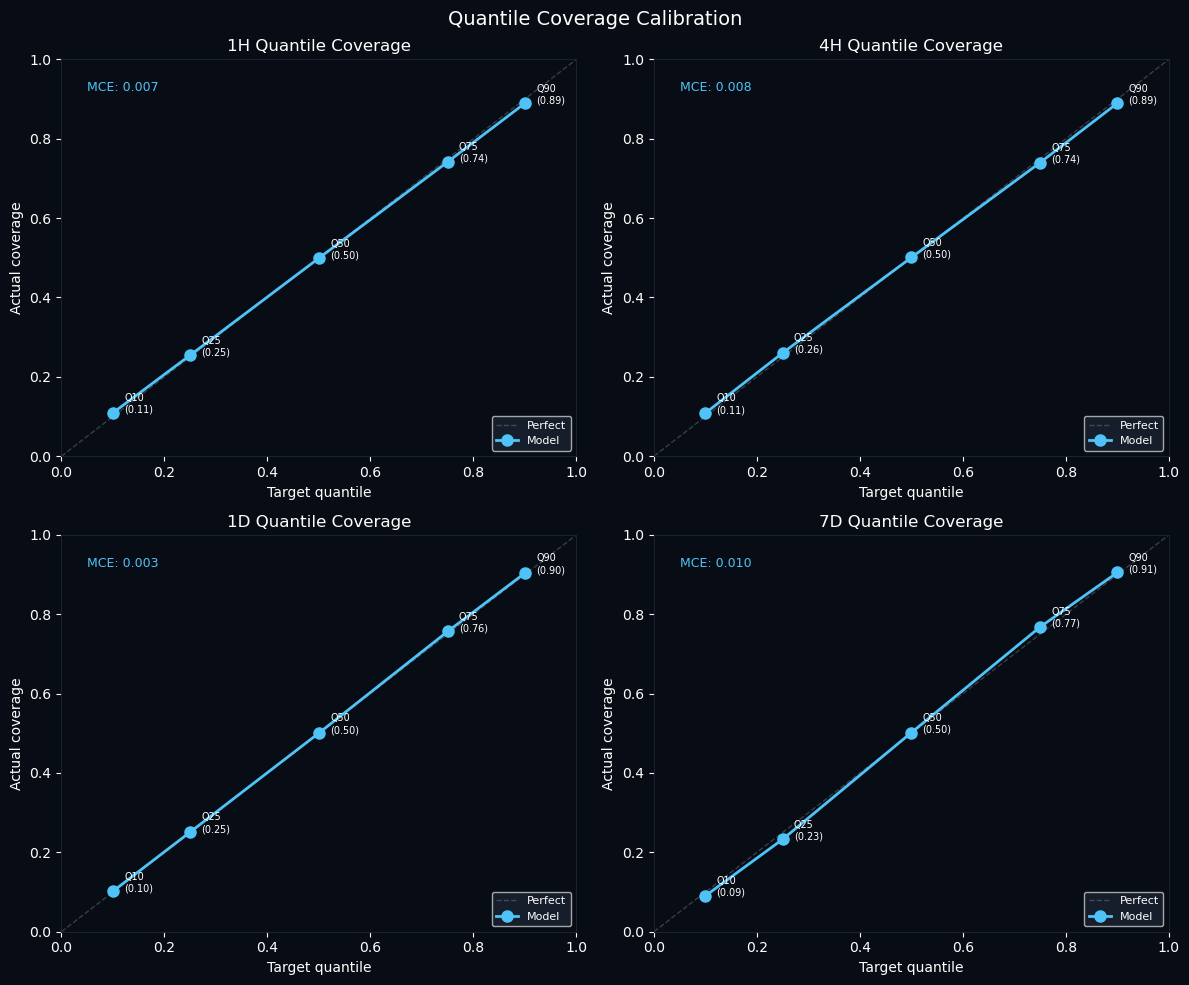

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor('#080c14')

for ax, horizon in zip(axes.flatten(), HORIZONS):
    ax.set_facecolor('#080c14')
    targets = QUANTILES
    actuals = [all_results[horizon][q]['coverage'] for q in QUANTILE_NAMES]

    ax.plot([0,1],[0,1],'--',color=(1,1,1,0.2),linewidth=1,label='Perfect')
    ax.plot(targets, actuals, 'o-', color='#4fc3f7', linewidth=2, markersize=8, label='Model')

    for t, a, name in zip(targets, actuals, QUANTILE_NAMES):
        ax.annotate(f'{name}\n({a:.2f})', (t, a), textcoords='offset points',
                    xytext=(8,0), color='white', fontsize=7)

    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Target quantile', color='white')
    ax.set_ylabel('Actual coverage', color='white')
    ax.set_title(f'{horizon} Quantile Coverage', color='white')
    ax.tick_params(colors='white')
    ax.legend(facecolor='#1a2332', labelcolor='white', fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

    mce = np.mean(np.abs(np.array(actuals) - np.array(targets)))
    ax.text(0.05, 0.92, f'MCE: {mce:.3f}', transform=ax.transAxes, color='#4fc3f7', fontsize=9)

plt.suptitle('Quantile Coverage Calibration', color='white', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Feature Importance (Q50 models)

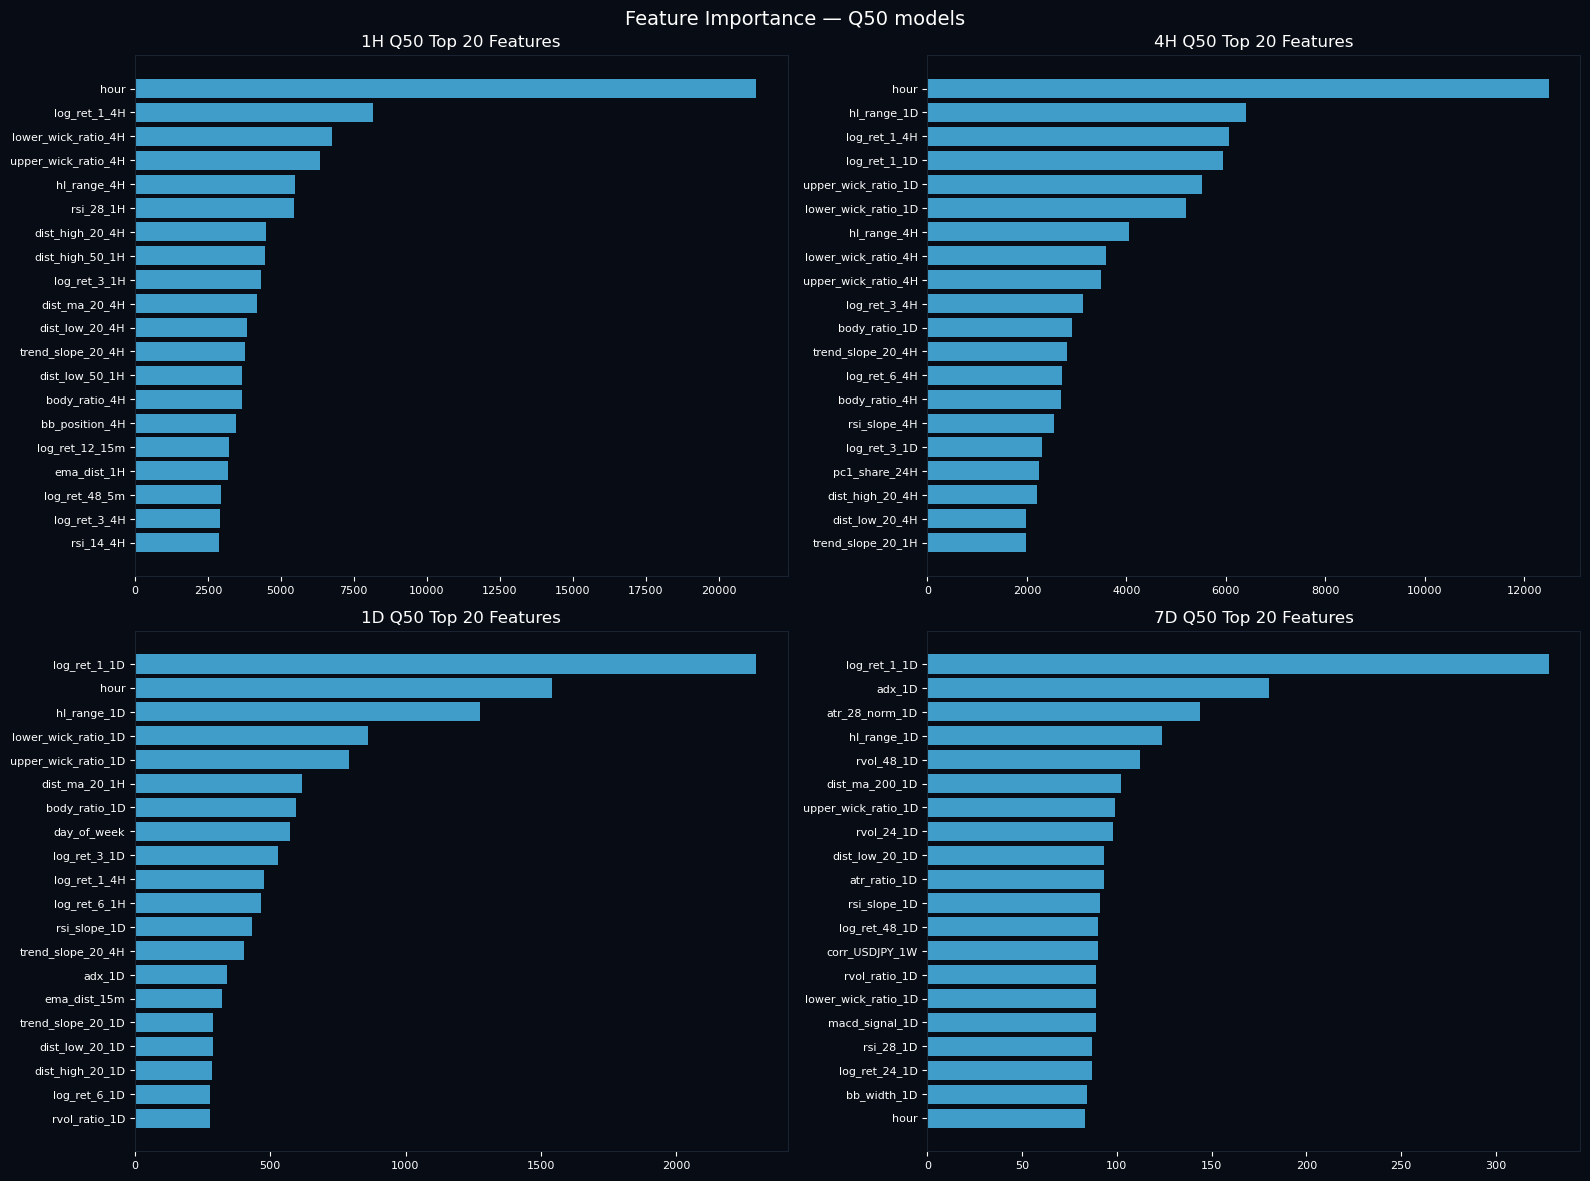

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#080c14')

for ax, horizon in zip(axes.flatten(), HORIZONS):
    bundle = joblib.load(MODELS_DIR / f'model_{horizon}_Q50.joblib')
    importance = pd.Series(bundle['model'].feature_importances_, index=feature_cols)
    importance = importance.sort_values(ascending=True).tail(20)

    ax.barh(importance.index, importance.values, color='#4fc3f7', alpha=0.8)
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=8)
    ax.set_title(f'{horizon} Q50 Top 20 Features', color='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('Feature Importance — Q50 models', color='white', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
print(df['pair'].unique())
print(df['pair'].dtype)
print(df[df['pair'] == 'EURUSD'].shape)

['EURUSD' 'GBPUSD' 'NZDUSD' 'AUDUSD' 'USDCHF' 'USDCAD' 'USDJPY']
object
(98323, 213)


In [13]:
pair = 'EURUSD'
horizon = '1H'

pair_data = df[df['pair'] == pair][feature_cols].dropna()
print(f'pair_data shape: {pair_data.shape}')

bundle = joblib.load(MODELS_DIR / f'model_{horizon}_Q50.joblib')
print(f'model feature count: {len(bundle["feature_cols"])}')
print(f'current feature count: {len(feature_cols)}')

# Check if feature cols match
saved_cols = set(bundle['feature_cols'])
current_cols = set(feature_cols)
print(f'Missing from current: {saved_cols - current_cols}')
print(f'Extra in current: {current_cols - saved_cols}')

pair_data shape: (0, 208)
model feature count: 208
current feature count: 208
Missing from current: set()
Extra in current: set()


## 7. Inference Test

In [14]:
def predict_quantiles(pair, horizon, df_features):
    pair_data = df_features[df_features['pair'] == pair][feature_cols].ffill().bfill()
    if len(pair_data) == 0: return None
    latest = pair_data.iloc[[-1]]

    q_preds = {}
    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        bundle = joblib.load(MODELS_DIR / f'model_{horizon}_Q{int(q*100)}.joblib')
        q_preds[q_name] = float(bundle['model'].predict(latest)[0])

    q50  = q_preds['Q50']
    qs   = np.array(QUANTILES)
    vals = np.array([q_preds[n] for n in QUANTILE_NAMES])

    if np.all(vals > 0):   p_down = 0.05
    elif np.all(vals < 0): p_down = 0.95
    else:                  p_down = float(np.interp(0, vals, qs))

    p_up = 1 - p_down
    direction = 'bearish' if p_down > p_up else 'bullish'
    probability = max(p_down, p_up)
    if probability < 0.55: direction = 'neutral'

    return {
        'pair': pair, 'horizon': horizon,
        'direction': direction, 'probability': round(probability, 4),
        'p_up': round(p_up, 4), 'p_down': round(p_down, 4),
        'expected_move_pct': round(q50 * 100, 4),
        'quantiles': {n: round(q_preds[n]*100, 4) for n in QUANTILE_NAMES},
        'cone': {
            'inner':  [round(q_preds['Q25']*100,4), round(q_preds['Q75']*100,4)],
            'outer':  [round(q_preds['Q10']*100,4), round(q_preds['Q90']*100,4)],
            'center': round(q50*100, 4),
        }
    }


print(f'{"Pair":<10} {"H":<6} {"Dir":<10} {"Prob":<8} {"Q50":<10} {"50% cone":<28} {"80% cone"}')
print('-' * 90)
for pair in ['EURUSD', 'GBPUSD', 'USDJPY']:
    for horizon in HORIZONS:
        r = predict_quantiles(pair, horizon, df)
        if r:
            c50 = f"[{r['cone']['inner'][0]:+.3f}%, {r['cone']['inner'][1]:+.3f}%]"
            c80 = f"[{r['cone']['outer'][0]:+.3f}%, {r['cone']['outer'][1]:+.3f}%]"
            print(f"{pair:<10} {horizon:<6} {r['direction'].upper():<10} {r['probability']*100:.1f}%   {r['expected_move_pct']:+.3f}%   {c50:<28} {c80}")

Pair       H      Dir        Prob     Q50        50% cone                     80% cone
------------------------------------------------------------------------------------------
EURUSD     1H     BEARISH    95.0%   -0.165%   [-0.158%, -0.153%]           [-0.153%, -0.116%]
EURUSD     4H     BEARISH    95.0%   -0.194%   [-0.252%, -0.139%]           [-0.238%, -0.062%]
EURUSD     1D     BEARISH    75.5%   -0.157%   [-0.279%, -0.006%]           [-0.439%, +0.182%]
EURUSD     7D     NEUTRAL    51.5%   -0.033%   [-0.680%, +0.492%]           [-1.059%, +0.785%]
GBPUSD     1H     BEARISH    95.0%   -0.043%   [-0.053%, -0.027%]           [-0.065%, -0.010%]
GBPUSD     4H     BULLISH    55.1%   +0.006%   [-0.023%, +0.060%]           [-0.065%, +0.075%]
GBPUSD     1D     BULLISH    55.3%   +0.034%   [-0.127%, +0.252%]           [-0.338%, +0.467%]
GBPUSD     7D     NEUTRAL    51.0%   +0.028%   [-0.670%, +0.714%]           [-1.377%, +1.268%]
USDJPY     1H     BULLISH    95.0%   +0.052%   [+0.040%, +0.04

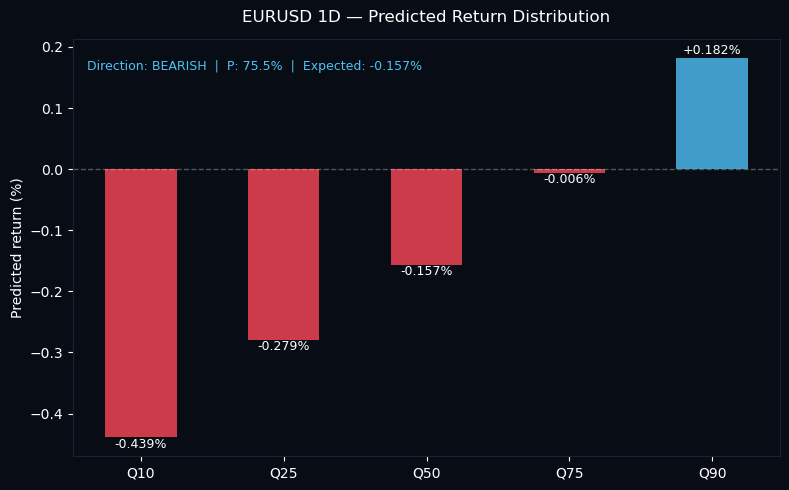

In [15]:
# Visualize quantile distribution for one pair
result = predict_quantiles('EURUSD', '1D', df)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#080c14')
ax.set_facecolor('#080c14')

qs   = list(result['quantiles'].keys())
vals = list(result['quantiles'].values())
colors = ['#ff4757' if v < 0 else '#4fc3f7' for v in vals]

ax.bar(qs, vals, color=colors, alpha=0.8, width=0.5)
ax.axhline(0, color=(1,1,1,0.3), linewidth=1, linestyle='--')

for i, (q, v) in enumerate(zip(qs, vals)):
    ax.text(i, v + (0.001 if v >= 0 else -0.001), f'{v:+.3f}%',
            ha='center', va='bottom' if v >= 0 else 'top', color='white', fontsize=9)

ax.set_title('EURUSD 1D — Predicted Return Distribution', color='white', pad=12)
ax.set_ylabel('Predicted return (%)', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
ax.text(0.02, 0.95,
        f"Direction: {result['direction'].upper()}  |  P: {result['probability']*100:.1f}%  |  Expected: {result['expected_move_pct']:+.3f}%",
        transform=ax.transAxes, color='#4fc3f7', fontsize=9, va='top')
plt.tight_layout()
plt.show()

In [17]:
# Confidence bucket accuracy
# For each probability bucket, what was the actual hit rate?

print('Confidence Bucket Analysis\n')
print(f'{"Bucket":<12} {"Predicted":<12} {"Actual":<12} {"Count":<10} {"Status"}')
print('-' * 55)

# Use holdout set (last 20% of data)
holdout_start = int(len(df) * 0.8)
df_holdout = df.iloc[holdout_start:]

for horizon in HORIZONS:
    print(f'\nHorizon: {horizon}')
    
    bundle_q50 = joblib.load(MODELS_DIR / f'model_{horizon}_Q50.joblib')
    
    X_hold = df_holdout[feature_cols].ffill().bfill()
    y_hold = df_holdout[f'label_{horizon}']
    
    # Get all 5 quantile predictions
    q_preds = {}
    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        bundle = joblib.load(MODELS_DIR / f'model_{horizon}_Q{int(q*100)}.joblib')
        q_preds[q_name] = bundle['model'].predict(X_hold)
    
    # Compute P(down) for each row
    p_downs = []
    for i in range(len(X_hold)):
        vals = np.array([q_preds[n][i] for n in QUANTILE_NAMES])
        qs   = np.array(QUANTILES)
        if np.all(vals > 0):   p_down = 0.01
        elif np.all(vals < 0): p_down = 0.99
        else:                  p_down = float(np.interp(0, vals, qs))
        p_downs.append(p_down)
    
    p_downs  = np.array(p_downs)
    y_actual = y_hold.values
    
    # For each row: dominant direction probability and whether it was correct
    p_dominant = np.where(p_downs > 0.5, p_downs, 1 - p_downs)
    correct     = np.where(p_downs > 0.5,
                           y_actual < 0,   # predicted down, was it down?
                           y_actual > 0)   # predicted up, was it up?
    
    # Bucket analysis
    buckets = [(0.50, 0.55), (0.55, 0.60), (0.60, 0.65), 
               (0.65, 0.70), (0.70, 0.80), (0.80, 0.90), (0.90, 1.00)]
    
    for low, high in buckets:
        mask = (p_dominant >= low) & (p_dominant < high)
        if mask.sum() < 20:
            continue
        actual_acc  = correct[mask].mean()
        pred_center = p_dominant[mask].mean()
        count       = mask.sum()
        gap         = actual_acc - pred_center
        status      = '✓' if abs(gap) < 0.05 else '✗'
        print(f'  {low:.0%}–{high:.0%}      {pred_center:.1%}        {actual_acc:.1%}        {count:<10} {status}  (gap: {gap:+.3f})')

Confidence Bucket Analysis

Bucket       Predicted    Actual       Count      Status
-------------------------------------------------------

Horizon: 1H
  50%–55%      52.4%        52.6%        23018      ✓  (gap: +0.002)
  55%–60%      57.4%        60.9%        17757      ✓  (gap: +0.035)
  60%–65%      62.4%        66.3%        12961      ✓  (gap: +0.039)
  65%–70%      67.4%        70.8%        9326       ✓  (gap: +0.035)
  70%–80%      75.5%        78.8%        20662      ✓  (gap: +0.033)
  80%–90%      84.8%        89.9%        21273      ✗  (gap: +0.051)
  90%–100%      99.0%        98.2%        32026      ✓  (gap: -0.007)

Horizon: 4H
  50%–55%      52.5%        57.3%        16711      ✓  (gap: +0.048)
  55%–60%      57.4%        64.1%        14610      ✗  (gap: +0.066)
  60%–65%      62.5%        69.0%        12657      ✗  (gap: +0.066)
  65%–70%      67.5%        72.9%        11734      ✗  (gap: +0.054)
  70%–80%      75.5%        81.6%        27515      ✗  (gap: +0.062)
  80

In [16]:
print('=' * 55)
print('TRAINING COMPLETE')
print('=' * 55)
print(f'Models saved: {len(list(MODELS_DIR.glob("*.joblib")))} files')
print(f'Location: {MODELS_DIR.resolve()}')
print(f'\nFiles:')
for f in sorted(MODELS_DIR.glob('*.joblib')):
    print(f'  {f.name:<35} {f.stat().st_size/1024/1024:.1f} MB')

TRAINING COMPLETE
Models saved: 20 files
Location: C:\Users\noual\lumeny\backend\models

Files:
  model_1D_Q10.joblib                 2.3 MB
  model_1D_Q25.joblib                 2.8 MB
  model_1D_Q50.joblib                 2.8 MB
  model_1D_Q75.joblib                 2.5 MB
  model_1D_Q90.joblib                 2.1 MB
  model_1H_Q10.joblib                 22.5 MB
  model_1H_Q25.joblib                 26.7 MB
  model_1H_Q50.joblib                 27.1 MB
  model_1H_Q75.joblib                 26.9 MB
  model_1H_Q90.joblib                 21.5 MB
  model_4H_Q10.joblib                 12.3 MB
  model_4H_Q25.joblib                 19.7 MB
  model_4H_Q50.joblib                 24.2 MB
  model_4H_Q75.joblib                 20.3 MB
  model_4H_Q90.joblib                 14.2 MB
  model_7D_Q10.joblib                 0.6 MB
  model_7D_Q25.joblib                 0.7 MB
  model_7D_Q50.joblib                 0.5 MB
  model_7D_Q75.joblib                 0.7 MB
  model_7D_Q90.joblib                 1